In [ ]:
from pathlib import Path
import xarray as xr
import utils
import numpy as np

In [ ]:
folder_path = 'Model_Data/CompleteData'
directory_path = Path(folder_path)

files_only = [folder_path + '/' + entry.name for entry in directory_path.iterdir() if entry.is_file() and entry.name != '.gitkeep']

def preprocess(ds):
    return ds.reset_index('valid_time', drop = True)
# ds = xr.open_mfdataset(files_only)
ds = xr.open_mfdataset(files_only, preprocess = preprocess)

In [107]:
ds_started = False
for i, file in enumerate(files_only):
    
    if not ds_started:
        ds = xr.open_dataset(file)
        ds = ds.assign_coords(frame_number = ('valid_time',np.arange(i*100, (i+1) * 100, 1)))
        ds = ds.swap_dims({'valid_time':'frame_number'})
        ds_started = True
    else:
        ds_temp = xr.open_dataset(file)
        ds_temp = ds_temp.assign_coords(frame_number = ('valid_time',np.arange(i*100, (i+1) * 100, 1)))
        ds_temp = ds_temp.swap_dims({'valid_time':'frame_number'})

        ds = xr.concat([ds, ds_temp], dim = 'frame_number')

In [110]:
ds1 = xr.open_dataset(files_only[0])
ds1 = ds1.assign_coords(frame_number = ('valid_time',np.arange(0, 100, 1)))
ds1 = ds1.swap_dims({'valid_time':'frame_number'})

(array([1.13510700e+06, 3.04475600e+07, 1.25176735e+08, 4.47811020e+07,
        1.08613010e+07, 2.55235700e+06, 1.07014900e+06, 2.61569000e+05,
        5.32450000e+04, 8.92300000e+03]),
 array([215.79689026, 218.38717651, 220.97744751, 223.56773376,
        226.15802002, 228.74829102, 231.33857727, 233.92886353,
        236.51914978, 239.10942078, 241.69970703]),
 <BarContainer object of 10 artists>)

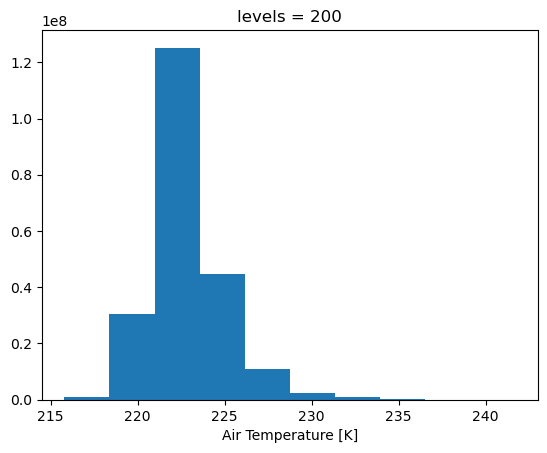

In [128]:
ds['t'].isel(levels = 2).plot.hist()